In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [22]:
df = pd.read_csv('./models/BFreqRatios.csv', skiprows=2,
                 usecols=[0, 1, 2], names=['freq', 'Rb87', 'Rb85'])


bAdjustment = 1.03360784475

freq = df['freq'].values
Rb87 = df['Rb87'].values / 10 * bAdjustment
Rb85 = df['Rb85'].values / 10 * bAdjustment

# print(freq)
# print(Rb87)
# print(Rb85)


m87, b87 = np.polyfit(freq, Rb87, deg=1)
m85, b85 = np.polyfit(freq, Rb85, deg=1)

xFit = np.linspace(min(freq),max(freq), num=200)
Rb87Fit = m87 * xFit + b87
Rb85Fit = m85 * xFit + b85

print(m87/m85)

1.5011150047814374


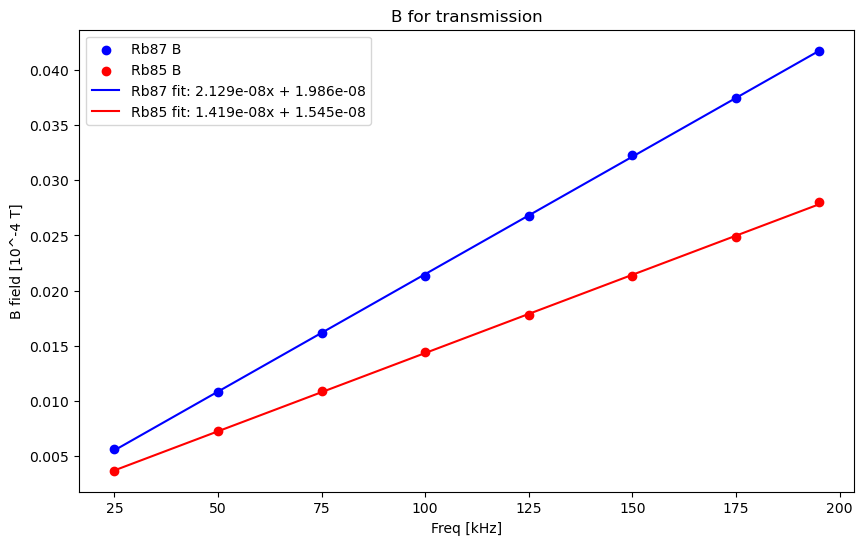

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(freq, Rb87 * 10**4, label='Rb87 B', color='blue')
plt.scatter(freq, Rb85 * 10**4, label='Rb85 B', color='red')

plt.plot(xFit, Rb87Fit * 10**4, label=f'Rb87 fit: {m87:.3e}x + {b87:.3e}', color='blue')
plt.plot(xFit, Rb85Fit * 10**4, label=f'Rb85 fit: {m85:.3e}x + {b85:.3e}', color='red')

# Labels and formatting
plt.xlabel('Freq [kHz]')
plt.ylabel('B field [10^-4 T]')
plt.title('B for transmission')
plt.legend()
plt.savefig("./figures/gfactor linear range Mar9", dpi=300)

plt.show()

In [23]:
df = pd.read_csv('./models/BFreqRatiosUncertain.csv', skiprows=2,
                 usecols=[0,2,3,4,5], names=['freq', 'Rb85', 'uRb85', 'Rb87', 'uRb87'])

freq = df['freq'].values
Rb87 = df['Rb87'].values * bAdjustment
Rb85 = df['Rb85'].values * bAdjustment
uRb87 = df['uRb87'].values * bAdjustment
uRb85 = df['uRb85'].values * bAdjustment

In [12]:
def linear_func(x, m, b):
    return m * x + b

def linear_0intercept(x, m):
    return m * x

In [24]:

popt, pcov = curve_fit(linear_func, freq, Rb87, sigma=uRb87, absolute_sigma=True)
perr87 = np.sqrt(np.diag(pcov))
m87 = ufloat(popt[0], perr87[0])
b87 = ufloat(popt[1], perr87[1])

popt, pcov = curve_fit(linear_func, freq, Rb85, sigma=uRb85, absolute_sigma=True)
perr85 = np.sqrt(np.diag(pcov))
m85 = ufloat(popt[0], perr87[0])
b85 = ufloat(popt[1], perr87[1])

xFit = np.linspace(min(freq),max(freq), num=200)
Rb87Fit = m87.n * xFit + b87.n
Rb85Fit = m85.n * xFit + b85.n


Rb87Residual = Rb87 - m87.n * freq - b87.n
Rb85Residual = Rb85 - m85.n * freq - b85.n


slopeRatio = m85/m87 # use 85/87 since the slope is the inverse (B over freq)

expectedSlopeRatio = ufloat(1.5,0)

tscore = (slopeRatio - expectedSlopeRatio).n/(slopeRatio - expectedSlopeRatio).s

print(f"Slope ratio: {slopeRatio:.3e}")
# print(f"expectedSlopeRatio : {expectedSlopeRatio:.3e}")
# print(f"slopeRatio - expectedSlopeRatio : {(slopeRatio - expectedSlopeRatio):.3e}")
print(f"Tscore : {tscore:.3e}")

h = 6.626 * 10**(-34) # J s
muB = 9.2740 * 10**(-24) # J/T

#B = h/(g_F mu_B) f
# m = h/(g_F mu_B) -> g_F = h/(m mu_B)
# m divided by 1000 to convert kHz to Hz
gF85 = h/(muB * m85 / 1000)
gF87 = h/(muB * m87 / 1000)

# below expected values are from Gemini AI, it cited https://steck.us/alkalidata/
# though I'm having a hard time finding these values explicitly

print(f"Rb87 gF: {gF87:.3e}, expect 0.4988")
print(f"Rb85 gF: {gF85:.3e}, expect 0.3337")

gF87Diff = gF87 / 0.4988
gF85Diff = gF85 / 0.3337

print(f"gF87Diff: {gF87Diff:.3e}")
print(f"gF87Diff: {gF85Diff:.3e}")

gFAvgDiff = gF87Diff*0.5 + gF85Diff*0.5

print(f"avg prop in gF: {gFAvgDiff:.3e}")

# Use these ratios (if they agree closely/by averaging them) to calibrate the B field experienced in the cell compared to what I *think* is being applied

print("the above values are off by a factor of around 1.04, use this to calibrate the B field measured to actual applied")


Slope ratio: (1.501+/-0.026)e+00
Tscore : 3.160e-02
Rb87 gF: (5.043+/-0.074)e-01, expect 0.4988
Rb85 gF: (3.360+/-0.033)e-01, expect 0.3337
gF87Diff: (1.011+/-0.015)e+00
gF87Diff: (1.007+/-0.010)e+00
avg prop in gF: (1.009+/-0.009)e+00
the above values are off by a factor of around 1.04, use this to calibrate the B field measured to actual applied


In [26]:

popt, pcov = curve_fit(linear_0intercept, freq, Rb87, sigma=uRb87, absolute_sigma=True)
perr87 = np.sqrt(np.diag(pcov))
m87 = ufloat(popt[0], perr87[0])

popt, pcov = curve_fit(linear_0intercept, freq, Rb85, sigma=uRb85, absolute_sigma=True)
perr85 = np.sqrt(np.diag(pcov))
m85 = ufloat(popt[0], perr87[0])

xFit = np.linspace(min(freq),max(freq), num=200)
Rb87Fit = m87.n * xFit
Rb85Fit = m85.n * xFit

Rb87Residual = Rb87 - m87.n * freq
Rb85Residual = Rb85 - m85.n * freq


slopeRatio = m85/m87 # use 85/87 since the slope is the inverse (B over freq)

expectedSlopeRatio = ufloat(1.5,0)

tscore = (slopeRatio - expectedSlopeRatio).n/(slopeRatio - expectedSlopeRatio).s

print(f"Slope ratio: {slopeRatio:.3e}")
# print(f"expectedSlopeRatio : {expectedSlopeRatio:.3e}")
# print(f"slopeRatio - expectedSlopeRatio : {(slopeRatio - expectedSlopeRatio):.3e}")
print(f"Tscore : {tscore:.3e}")

h = 6.626 * 10**(-34) # J s
muB = 9.2740 * 10**(-24) # J/T

#B = h/(g_F mu_B) f
# m = h/(g_F mu_B) -> g_F = h/(m mu_B)
# m divided by 1000 to convert kHz to Hz
gF85 = h/(muB * m85 / 1000)
gF87 = h/(muB * m87 / 1000)

# below expected values are from Gemini AI, it cited https://steck.us/alkalidata/
# though I'm having a hard time finding these values explicitly

print(f"Rb87 gF: {gF87:.3e}, expect 0.4988")
print(f"Rb85 gF: {gF85:.3e}, expect 0.3337")

gF87Diff = gF87 / 0.4988
gF85Diff = gF85 / 0.3337

print(f"gF87Diff: {gF87Diff:.3e}")
print(f"gF87Diff: {gF85Diff:.3e}")

gFAvgDiff = gF87Diff*0.5 + gF85Diff*0.5

print(f"avg prop in gF: {gFAvgDiff:.3e}")

# Use these ratios (if they agree closely/by averaging them) to calibrate the B field experienced in the cell compared to what I *think* is being applied

print("the above values are off by a factor of around 1.04, use this to calibrate the B field measured to actual applied")


Slope ratio: (1.499+/-0.013)e+00
Tscore : -4.561e-02
Rb87 gF: (4.996+/-0.036)e-01, expect 0.4988
Rb85 gF: (3.332+/-0.016)e-01, expect 0.3337
gF87Diff: (1.002+/-0.007)e+00
gF87Diff: (9.985+/-0.048)e-01
avg prop in gF: (1.000+/-0.004)e+00
the above values are off by a factor of around 1.04, use this to calibrate the B field measured to actual applied


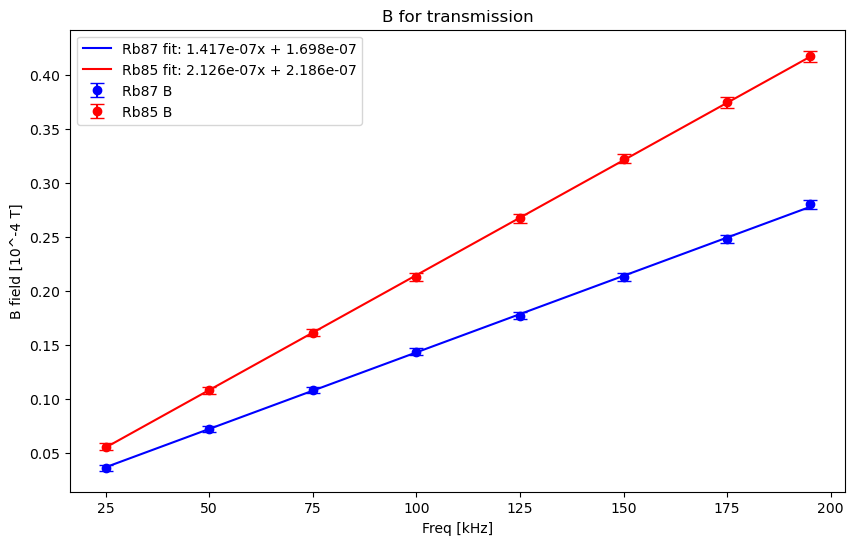

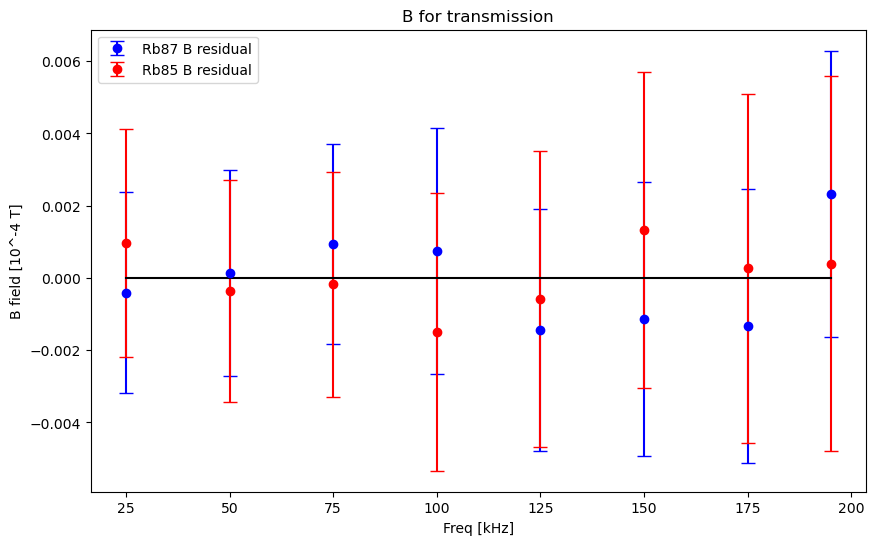

In [25]:
plt.figure(figsize=(10, 6))
plt.errorbar(freq, Rb87 * 10**4, yerr=uRb87 * 10**4, label='Rb87 B', capsize=5, fmt='o', color='blue')
plt.errorbar(freq, Rb85 * 10**4, yerr=uRb85 * 10**4, label='Rb85 B', capsize=5, fmt='o', color='red')

plt.plot(xFit, Rb87Fit * 10**4, label=f'Rb87 fit: {m87.n:.3e}x + {b87.n:.3e}', color='blue')
plt.plot(xFit, Rb85Fit * 10**4, label=f'Rb85 fit: {m85.n:.3e}x + {b85.n:.3e}', color='red')

# Labels and formatting
plt.xlabel('Freq [kHz]')
plt.ylabel('B field [10^-4 T]')
plt.title('B for transmission')
plt.legend()
plt.savefig("./figures/gfactor linear range Mar 9", dpi=300)

plt.show()



plt.figure(figsize=(10, 6))
plt.errorbar(freq, Rb87Residual * 10**4, yerr=uRb87 * 10**4,label='Rb87 B residual', capsize=5, fmt='o', color='blue')
plt.errorbar(freq, Rb85Residual * 10**4, yerr=uRb85 * 10**4, label='Rb85 B residual', capsize=5, fmt='o', color='red')

plt.plot(xFit, np.zeros_like(xFit), color='black')
# plt.plot(xFit, np.zeros(xFit), label=f'Rb85 fit: {m85.n:.3e}x + {b85.n:.3e}', color='red')

# Labels and formatting
plt.xlabel('Freq [kHz]')
plt.ylabel('B field [10^-4 T]')
plt.title('B for transmission')
plt.legend()
plt.savefig("./figures/gfactor linear range residual Mar 9", dpi=300)

plt.show()